In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import StackingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import math



In [2]:
# Upload and load the dataset
from google.colab import files
uploaded = files.upload()

Saving DATASET.xlsx to DATASET.xlsx


In [26]:
# . DATA LOADING AND EXPLORATION
# Load the dataset. Upload Excel file to Colab and update the path
df = pd.read_excel('/content/DATASET.xlsx')

print(f"Dataset Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nStatistical Summary:")
statistical_summary = df.describe().loc[['count', 'mean', 'std', '25%', '50%', '75%']]
display(statistical_summary)
print(statistical_summary.to_string())

Dataset Shape: (1710, 13)
Columns: ['IOLtype', 'CCT', 'AQD', 'ACD', 'LT', 'AL', 'R1', 'R2', 'K1', 'K2', 'WTW', 'IOL', 'SEQ']

Statistical Summary:


,CCT,AQD,ACD,LT,AL,R1,R2,K1,K2,WTW,IOL,SEQ
count,1710.000000,1710.000000,1710.000000,1710.000000,1710.000000,1710.000000,1710.000000,1710.000000,1710.000000,1710.000000,1710.000000,1710.000000
mean,0.557398,2.561429,3.118827,4.617291,23.642370,7.821741,7.646411,43.204344,44.196245,12.040248,21.635105,-0.522637
std,0.035894,0.413005,0.412429,0.446218,1.533590,0.280335,0.275612,1.548774,1.609234,0.416884,4.300356,0.832744
25%,0.534000,2.286065,2.833250,4.330000,22.736983,7.639802,7.460319,42.240300,43.136092,12.035519,19.500000,-0.750000
50%,0.557000,2.560000,3.109000,4.600000,23.514446,7.830000,7.660000,43.103448,44.060052,12.047646,22.000000,-0.250000
75%,0.582000,2.847737,3.407000,4.904258,24.400892,7.990000,7.824075,44.176539,45.239351,12.072104,23.500000,0.000000


               CCT          AQD          ACD           LT           AL           R1           R2           K1           K2          WTW          IOL          SEQ
count  1710.000000  1710.000000  1710.000000  1710.000000  1710.000000  1710.000000  1710.000000  1710.000000  1710.000000  1710.000000  1710.000000  1710.000000
mean      0.557398     2.561429     3.118827     4.617291    23.642370     7.821741     7.646411    43.204344    44.196245    12.040248    21.635105    -0.522637
std       0.035894     0.413005     0.412429     0.446218     1.533590     0.280335     0.275612     1.548774     1.609234     0.416884     4.300356     0.832744
25%       0.534000     2.286065     2.833250     4.330000    22.736983     7.639802     7.460319    42.240300    43.136092    12.035519    19.500000    -0.750000
50%       0.557000     2.560000     3.109000     4.600000    23.514446     7.830000     7.660000    43.103448    44.060052    12.047646    22.000000    -0.250000
75%       0.582000     2.847

In [4]:
df = pd.read_excel(next(iter(uploaded)))

=== COMPREHENSIVE CORRELATION ANALYSIS ===
Dataset shape: (1710, 12)
Numeric columns: ['CCT', 'AQD', 'ACD', 'LT', 'AL', 'R1', 'R2', 'K1', 'K2', 'WTW', 'IOL', 'SEQ']

Correlation Matrix:
       CCT    AQD    ACD     LT     AL     R1     R2     K1     K2    WTW  \
CCT  1.000 -0.059  0.027 -0.005  0.054  0.201  0.205 -0.203 -0.206  0.009   
AQD -0.059  1.000  0.996 -0.617  0.569  0.055  0.062 -0.052 -0.060  0.194   
ACD  0.027  0.996  1.000 -0.618  0.575  0.072  0.080 -0.070 -0.078  0.195   
LT  -0.005 -0.617 -0.618  1.000 -0.223 -0.015  0.012  0.009 -0.016 -0.039   
AL   0.054  0.569  0.575 -0.223  1.000  0.359  0.344 -0.359 -0.342  0.209   
R1   0.201  0.055  0.072 -0.015  0.359  1.000  0.871 -0.998 -0.867  0.288   
R2   0.205  0.062  0.080  0.012  0.344  0.871  1.000 -0.876 -0.999  0.283   
K1  -0.203 -0.052 -0.070  0.009 -0.359 -0.998 -0.876  1.000  0.874 -0.286   
K2  -0.206 -0.060 -0.078 -0.016 -0.342 -0.867 -0.999  0.874  1.000 -0.280   
WTW  0.009  0.194  0.195 -0.039  0.209  0.28

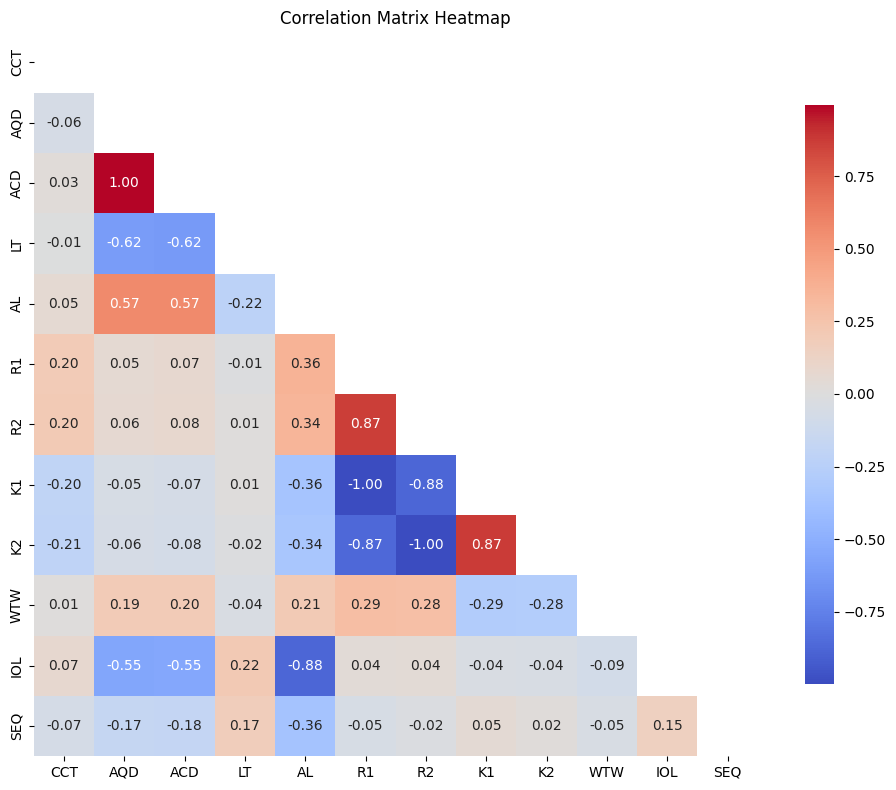


Strong Correlations (|r| > 0.5):
AQD - ACD: 0.996
ACD - AQD: 0.996
K1 - K2: 0.874
K2 - K1: 0.874
R2 - R1: 0.871
R1 - R2: 0.871
ACD - AL: 0.575
AL - ACD: 0.575
AQD - AL: 0.569
AL - AQD: 0.569
ACD - IOL: -0.549
IOL - ACD: -0.549
AQD - IOL: -0.555
IOL - AQD: -0.555
LT - AQD: -0.617
AQD - LT: -0.617
LT - ACD: -0.618
ACD - LT: -0.618
R1 - K2: -0.867
K2 - R1: -0.867
R2 - K1: -0.876
K1 - R2: -0.876
IOL - AL: -0.880
AL - IOL: -0.880
R1 - K1: -0.998
K1 - R1: -0.998
R2 - K2: -0.999
K2 - R2: -0.999


In [5]:

import matplotlib.pyplot as plt
import seaborn as sns


# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

print("=== COMPREHENSIVE CORRELATION ANALYSIS ===")

# Basic stats
print(f"Dataset shape: {numeric_df.shape}")
print(f"Numeric columns: {list(numeric_df.columns)}")

# Correlation matrix
corr_matrix = numeric_df.corr()
print("\nCorrelation Matrix:")
print(corr_matrix.round(3))

# Heatmap visualization
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

# Strong correlations only (above threshold)
threshold = 0.5
strong_correlations = corr_matrix[(corr_matrix.abs() > threshold) & (corr_matrix != 1.0)]
strong_correlations = strong_correlations.unstack().dropna().sort_values(ascending=False)

print(f"\nStrong Correlations (|r| > {threshold}):")
if not strong_correlations.empty:
    for idx, value in strong_correlations.items():
        print(f"{idx[0]} - {idx[1]}: {value:.3f}")
else:
    print("No strong correlations found above the threshold.")

In [6]:
# Select features and target
features = ["IOLtype", "ACD", "LT", "AL", "K1", "K2", "WTW", "IOL"]
target = "SEQ"
X = df[features].copy()
y = df[target]

# Encode categorical feature
le = LabelEncoder()
X['IOLtype'] = le.fit_transform(X['IOLtype'])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale numerical features
scaler = StandardScaler()
cols_to_scale = ["ACD", "LT", "AL", "K1", "K2", "WTW", "IOL"]
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])


# Define base models (level-1 learners)
base_learners = [
    ('mlp', MLPRegressor(
        random_state=42,
        max_iter=1000,
        activation='relu',
        alpha=0.1,
        hidden_layer_sizes=(200,),
        learning_rate_init=0.011724726450932652
    )),
    ('spline_linear', Pipeline([
        ('spline', SplineTransformer(degree=2, n_knots=6)),
        ('linear', LinearRegression())
    ])),
    ('svr', SVR(
        kernel='rbf',
        C=30,
        epsilon=0.1,
        gamma=0.03
    ))
]

# Define meta-model (level-2 learner)
meta_learner = Ridge(random_state=42)

# Build stacking regressor
stacking_reg = StackingRegressor(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    passthrough=False,
    n_jobs=-1
)

# Cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)
mse_scores = cross_val_score(stacking_reg, X_train_scaled, y_train, cv=cv, scoring='neg_mean_squared_error')
mae_scores = cross_val_score(stacking_reg, X_train_scaled, y_train, cv=cv, scoring='neg_mean_absolute_error')
print("CV Mean MSE:", -np.mean(mse_scores))
print("CV Mean MAE:", -np.mean(mae_scores))

# Individual base learner performance (Cross-validation)
# --------------------------
print("\n=== Cross-validation Performance of Individual Models ===")
for name, model in base_learners:
    mse_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='neg_mean_squared_error')
    mae_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='neg_mean_absolute_error')

    print(f"\n{name} CV Performance:")
    print(f"  CV Mean MSE: {-mse_scores.mean():.4f}")
    print(f"  CV Mean MAE: {-mae_scores.mean():.4f}")

# Fit and evaluate ML model
stacking_reg.fit(X_train_scaled, y_train)
y_pred = stacking_reg.predict(X_test_scaled)

print("ML Model Test MSE:", mean_squared_error(y_test, y_pred))
print("ML Model Test MAE:", mean_absolute_error(y_test, y_pred))
print("ML Model Test R2:", r2_score(y_test, y_pred))

# Individual base learner performance (Test set, after stacking fit)
# --------------------------
print("\n=== Test Performance of Individual Models (from stacking) ===")
for name, fitted_model in stacking_reg.named_estimators_.items():
    y_pred_ind = fitted_model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred_ind)
    mae = mean_absolute_error(y_test, y_pred_ind)
    r2 = r2_score(y_test, y_pred_ind)

    print(f"\n{name} Test Performance:")
    print(f"  Test MSE: {mse:.4f}")
    print(f"  Test MAE: {mae:.4f}")
    print(f"  Test R2 : {r2:.4f}")

CV Mean MSE: 0.14405024080822995
CV Mean MAE: 0.2909850765811168

=== Cross-validation Performance of Individual Models ===

mlp CV Performance:
  CV Mean MSE: 0.1904
  CV Mean MAE: 0.3171

spline_linear CV Performance:
  CV Mean MSE: 0.1445
  CV Mean MAE: 0.2935

svr CV Performance:
  CV Mean MSE: 0.1529
  CV Mean MAE: 0.2946
ML Model Test MSE: 0.12104226152372712
ML Model Test MAE: 0.27113451626889207
ML Model Test R2: 0.8084542229797307

=== Test Performance of Individual Models (from stacking) ===

mlp Test Performance:
  Test MSE: 0.1375
  Test MAE: 0.2882
  Test R2 : 0.7824

spline_linear Test Performance:
  Test MSE: 0.1245
  Test MAE: 0.2751
  Test R2 : 0.8029

svr Test Performance:
  Test MSE: 0.1252
  Test MAE: 0.2762
  Test R2 : 0.8018


In [7]:
# Get training predictions and metrics(Overfitting Check)
y_train_pred = stacking_reg.predict(X_train_scaled)

print("\n=== Training vs Test Performance (Overfitting Check) ===")
print("Training MAE:", mean_absolute_error(y_train, y_train_pred))
print("Test MAE:    ", mean_absolute_error(y_test, y_pred))

print("Training MSE:", mean_squared_error(y_train, y_train_pred))
print("Test MSE:    ", mean_squared_error(y_test, y_pred))

print("Training R2: ", r2_score(y_train, y_train_pred))
print("Test R2:     ", r2_score(y_test, y_pred))


=== Training vs Test Performance (Overfitting Check) ===
Training MAE: 0.2662982090619708
Test MAE:     0.27113451626889207
Training MSE: 0.11644894010413209
Test MSE:     0.12104226152372712
Training R2:  0.8355626716495866
Test R2:      0.8084542229797307


In [8]:
# Check individual models for overfitting
print("\n=== Individual Models Overfitting Check ===")
for name, model in base_learners:
    model.fit(X_train_scaled, y_train)
    y_train_pred_ind = model.predict(X_train_scaled)
    y_test_pred_ind = model.predict(X_test_scaled)

    train_mae = mean_absolute_error(y_train, y_train_pred_ind)
    test_mae = mean_absolute_error(y_test, y_test_pred_ind)

    print(f"{name}: Train MAE = {train_mae:.4f}, Test MAE = {test_mae:.4f}, Difference = {train_mae-test_mae:.4f}")


=== Individual Models Overfitting Check ===
mlp: Train MAE = 0.2720, Test MAE = 0.2882, Difference = -0.0162
spline_linear: Train MAE = 0.2788, Test MAE = 0.2751, Difference = 0.0038
svr: Train MAE = 0.2573, Test MAE = 0.2762, Difference = -0.0189


In [9]:
#Display meta-learner coefficients and intercept
# --------------------------
print("\n=== Meta-Learner Coefficients (Ridge) ===")

# Get the meta-learner (final estimator) from the stacking regressor
meta_model = stacking_reg.final_estimator_

# Get the feature names for the meta-learner (base model predictions)
base_model_names = [name for name, _ in base_learners]
meta_feature_names = base_model_names

# Extract coefficients and intercept
coefs = dict(zip(meta_feature_names, meta_model.coef_.tolist()))
intercept = float(meta_model.intercept_)

# Display the results
coefficient_dict = {'intercept': intercept, **coefs}
print("Meta-learner coefficients (weighting of base model predictions):")


coefficients_df = pd.DataFrame({
    'Base_Model': list(coefficient_dict.keys()),
    'Coefficient': list(coefficient_dict.values())
})

print(coefficients_df.to_string(index=False))


=== Meta-Learner Coefficients (Ridge) ===
Meta-learner coefficients (weighting of base model predictions):
   Base_Model  Coefficient
    intercept     0.002532
          mlp     0.247588
spline_linear     0.561108
          svr     0.204931


In [10]:
#  Output y_test, y_pred, and Residuals
print("\n" + "="*60)
print("PREDICTION RESULTS: y_test, y_pred, and Residuals")
print("="*60)

# Create a DataFrame for clear output
results_df = pd.DataFrame({
    'y_test_actual': y_test.values,
    'y_pred': y_pred,
    'Residuals': y_test.values - y_pred
})

# Display first 5 rows
print("\nFirst 5 predictions:")
print(results_df.head(5).to_string(index=False))


PREDICTION RESULTS: y_test, y_pred, and Residuals

First 5 predictions:
 y_test_actual    y_pred  Residuals
         -2.00 -1.910397  -0.089603
         -0.75 -0.426486  -0.323514
         -0.25 -0.332569   0.082569
          0.13  0.221040  -0.091040
         -0.25 -0.142374  -0.107626



GENERATING PLOTS...


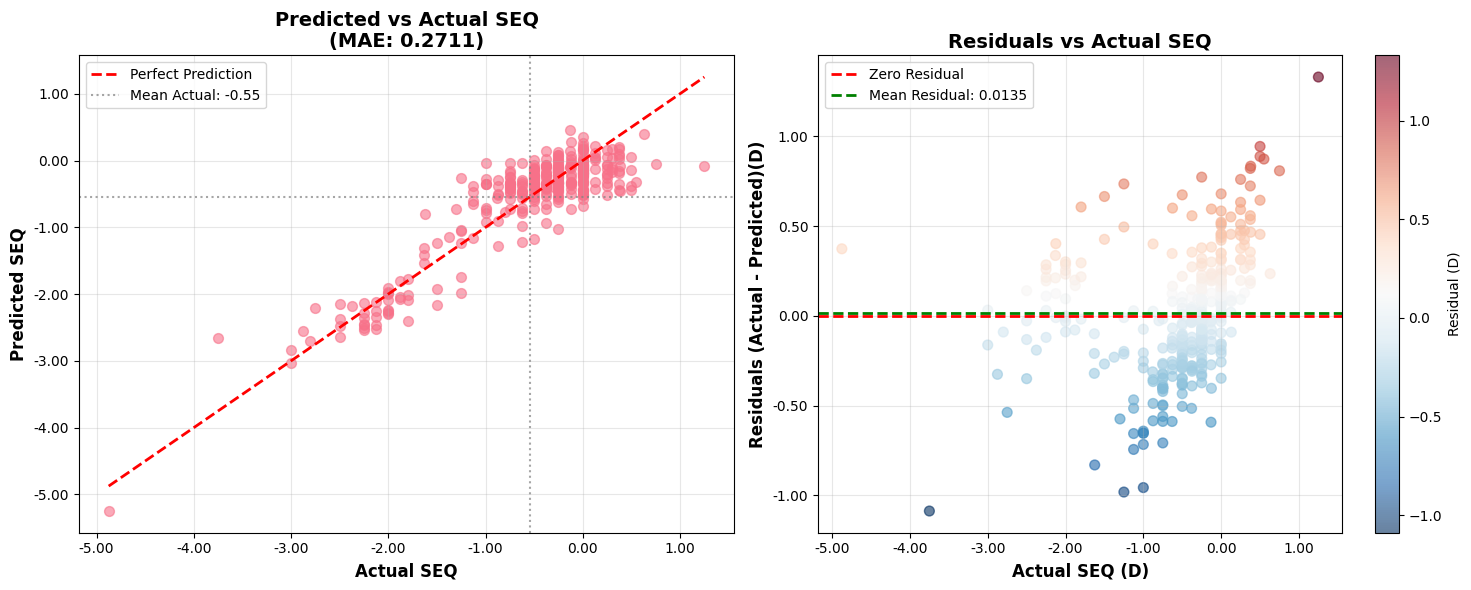

In [11]:
#  Plot 1: Predicted vs Actual SEQ with MAE annotated
print("\n" + "="*60)
print("GENERATING PLOTS...")
print("="*60)

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Predicted vs Actual SEQ
scatter1 = ax1.scatter(y_test, y_pred, alpha=0.6, s=50)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')

# Calculate MAE and add to plot
mae = mean_absolute_error(y_test, y_pred)
ax1.axhline(y=y_test.mean(), color='gray', linestyle=':', alpha=0.7, label=f'Mean Actual: {y_test.mean():.2f}')
ax1.axvline(x=y_test.mean(), color='gray', linestyle=':', alpha=0.7)

# Customize the first plot
ax1.set_xlabel('Actual SEQ', fontsize=12, fontweight='bold')
ax1.set_ylabel('Predicted SEQ', fontsize=12, fontweight='bold')
ax1.set_title('Predicted vs Actual SEQ\n(MAE: {:.4f})'.format(mae), fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)


# Format axes to show proper decimal places
ax1.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# Plot 2: Residuals vs Actual SEQ
residuals = y_test - y_pred
scatter2 = ax2.scatter(y_test, residuals, alpha=0.6, s=50, c=residuals, cmap='RdBu_r')

# Add zero line and mean lines
ax2.axhline(y=0, color='red', linestyle='--', lw=2, label='Zero Residual')
ax2.axhline(y=residuals.mean(), color='green', linestyle='--', lw=2,
           label=f'Mean Residual: {residuals.mean():.4f}')

# Customize the second plot
ax2.set_xlabel('Actual SEQ (D)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Residuals (Actual - Predicted)(D)', fontsize=12, fontweight='bold')
ax2.set_title('Residuals vs Actual SEQ', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Add colorbar for residuals
plt.colorbar(scatter2, ax=ax2, label='Residual (D)')

# Format axes
ax2.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# Adjust layout and show
plt.tight_layout()
plt.show()

In [12]:
# Additional Diagnostic Information
print("\n" + "="*60)
print("RESIDUAL ANALYSIS")
print("="*60)

# Residual statistics
print(f"Residual Statistics:")
print(f"Mean: {residuals.mean():.6f}")
print(f"Standard Deviation: {residuals.std():.6f}")
print(f"Min: {residuals.min():.6f}")
print(f"Max: {residuals.max():.6f}")
print(f"Range: {residuals.max() - residuals.min():.6f}")

# Check for patterns in residuals
from scipy import stats
print(f"\nResidual Normality Test (Shapiro-Wilk):")
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"W-statistic: {shapiro_stat:.4f}, p-value: {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print("Residuals appear normally distributed")
else:
    print("Residuals may not be normally distributed")


RESIDUAL ANALYSIS
Residual Statistics:
Mean: 0.013491
Standard Deviation: 0.348159
Min: -1.087473
Max: 1.330069
Range: 2.417542

Residual Normality Test (Shapiro-Wilk):
W-statistic: 0.9941, p-value: 0.2081
Residuals appear normally distributed


In [13]:
# OVERFITTING ANALYSIS
print("\n" + "="*60)
print("OVERFITTING ANALYSIS: Training vs Test Performance")
print("="*60)

# Get predictions on training data
y_pred_train = stacking_reg.predict(X_train_scaled)

# Calculate metrics for both sets
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred)

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred)

print("Performance Comparison:")
print(f"{'Metric':<15} {'Training':<10} {'Test':<10} {'Difference':<12} {'Status'}")
print("-" * 60)
print(f"{'MSE':<15} {train_mse:.4f}     {test_mse:.4f}     {train_mse-test_mse:+.4f}    {' GOOD' if test_mse <= train_mse * 1.1 else ' OVERFITTING'}")
print(f"{'MAE':<15} {train_mae:.4f}     {test_mae:.4f}     {train_mae-test_mae:+.4f}    {' GOOD' if test_mae <= train_mae * 1.1 else 'OVERFITTING'}")
print(f"{'R²':<15} {train_r2:.4f}     {test_r2:.4f}     {train_r2-test_r2:+.4f}    {' GOOD' if abs(train_r2 - test_r2) <= 0.05 else ' OVERFITTING'}")

# Rule of thumb thresholds
if test_mse > train_mse * 1.15:  # Test MSE > 15% worse than training
    print("\n SIGNIFICANT OVERFITTING DETECTED: Test MSE much worse than training")
elif test_mse > train_mse * 1.05:  # Test MSE > 5% worse than training
    print("\n MILD OVERFITTING DETECTED: Test performance slightly worse than training")
else:
    print("\n GOOD GENERALIZATION: Model performs similarly on training and test data")


OVERFITTING ANALYSIS: Training vs Test Performance
Performance Comparison:
Metric          Training   Test       Difference   Status
------------------------------------------------------------
MSE             0.1164     0.1210     -0.0046     GOOD
MAE             0.2663     0.2711     -0.0048     GOOD
R²              0.8356     0.8085     +0.0271     GOOD

 GOOD GENERALIZATION: Model performs similarly on training and test data


In [14]:
# Compare CV performance with test performance
print("\n" + "="*60)
print("CROSS-VALIDATION vs TEST SET CONSISTENCY")
print("="*60)

cv_mse_mean = -np.mean(mse_scores)  # From your existing CV code
cv_mae_mean = -np.mean(mae_scores)

print(f"{'Metric':<15} {'CV Mean':<10} {'Test':<10} {'Ratio (Test/CV)':<15}")
print("-" * 50)
print(f"{'MSE':<15} {cv_mse_mean:.4f}    {test_mse:.4f}    {test_mse/cv_mse_mean:.2f}x")
print(f"{'MAE':<15} {cv_mae_mean:.4f}    {test_mae:.4f}    {test_mae/cv_mae_mean:.2f}x")

# Interpretation
mse_ratio = test_mse / cv_mse_mean
if mse_ratio > 1.2:
    print(f"\n OVERFITTING: Test MSE is {mse_ratio:.1f}x worse than CV mean")
elif mse_ratio > 1.1:
    print(f"\n Potential overfitting: Test MSE is {mse_ratio:.1f}x worse than CV mean")
else:
    print(f"\n GOOD: Test performance consistent with CV")


CROSS-VALIDATION vs TEST SET CONSISTENCY
Metric          CV Mean    Test       Ratio (Test/CV)
--------------------------------------------------
MSE             0.1529    0.1210    0.79x
MAE             0.2946    0.2711    0.92x

 GOOD: Test performance consistent with CV


In [15]:
#Comprehensive overfitting check
def check_overfitting(model, X_train, y_train, X_test, y_test, cv_scores=None):
    """Comprehensive overfitting check"""

    # 1. Training vs Test performance
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)

    # 2. Calculate overfitting metrics
    mse_ratio = test_mse / train_mse
    performance_gap = test_mse - train_mse

    print("\n" + "="*60)
    print("COMPREHENSIVE OVERFITTING ANALYSIS")
    print("="*60)

    print(f"Training MSE: {train_mse:.6f}")
    print(f"Test MSE:     {test_mse:.6f}")
    print(f"Test/Train Ratio: {mse_ratio:.3f}")
    print(f"Performance Gap:  {performance_gap:.6f}")

    # 3. Overfitting assessment
    if mse_ratio > 1.5:
        status = " SEVERE OVERFITTING"
    elif mse_ratio > 1.2:
        status = " MODERATE OVERFITTING"
    elif mse_ratio > 1.1:
        status = " MILD OVERFITTING"
    elif mse_ratio > 0.9:
        status = " GOOD GENERALIZATION"
    else:
        status = " UNDERFITTING (test better than train)"

    print(f"\nStatus: {status}")

    return mse_ratio, performance_gap

# Run the comprehensive check
mse_ratio, gap = check_overfitting(stacking_reg, X_train_scaled, y_train, X_test_scaled, y_test)


COMPREHENSIVE OVERFITTING ANALYSIS
Training MSE: 0.116449
Test MSE:     0.121042
Test/Train Ratio: 1.039
Performance Gap:  0.004593

Status:  GOOD GENERALIZATION



RESIDUAL PATTERN ANALYSIS


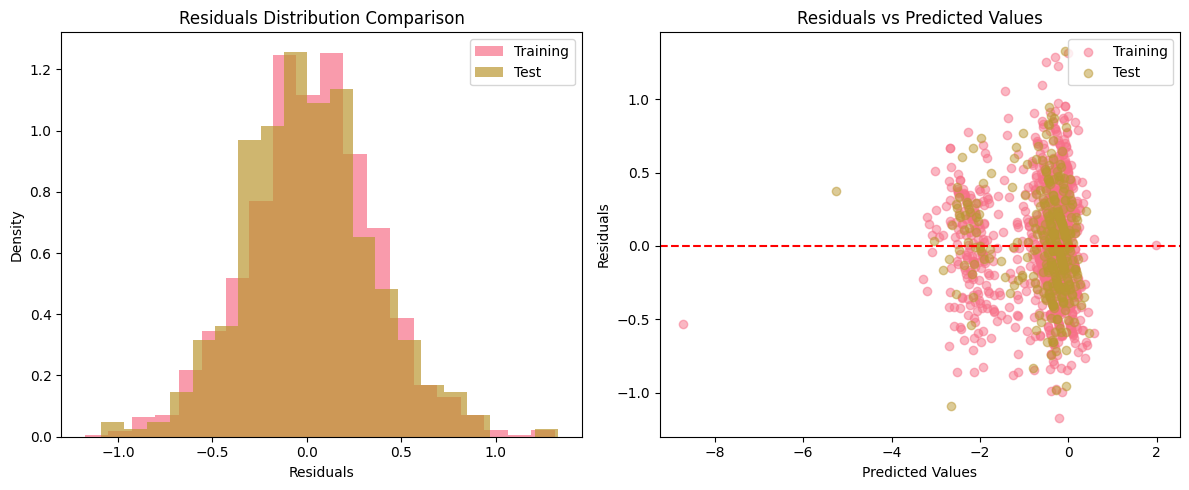

Training Residuals - Mean: 0.0296
Test Residuals - Mean: 0.0135
 Consistent residuals variance across sets


In [16]:
# Analyze residuals pattern
print("\n" + "="*60)
print("RESIDUAL PATTERN ANALYSIS")
print("="*60)

# Calculate residuals for both sets
residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred

plt.figure(figsize=(12, 5))

# Plot 1: Residuals distribution comparison
plt.subplot(1, 2, 1)
plt.hist(residuals_train, alpha=0.7, label='Training', bins=20, density=True)
plt.hist(residuals_test, alpha=0.7, label='Test', bins=20, density=True)
plt.xlabel('Residuals')
plt.ylabel('Density')
plt.title('Residuals Distribution Comparison')
plt.legend()

# Plot 2: Residuals vs Predicted values
plt.subplot(1, 2, 2)
plt.scatter(y_pred_train, residuals_train, alpha=0.5, label='Training')
plt.scatter(y_pred, residuals_test, alpha=0.5, label='Test')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.legend()

plt.tight_layout()
plt.show()

# Statistical comparison
print(f"Training Residuals - Mean: {residuals_train.mean():.4f}")
print(f"Test Residuals - Mean: {residuals_test.mean():.4f}")

if abs(residuals_test.std() - residuals_train.std()) > residuals_train.std() * 0.3:
    print(" Large difference in residuals variance suggests overfitting")
else:
    print(" Consistent residuals variance across sets")


Quick Visual Overfitting Check...


/tmp/ipykernel_9347/1440716529.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([residuals_train, residuals_test], labels=['Train', 'Test'])


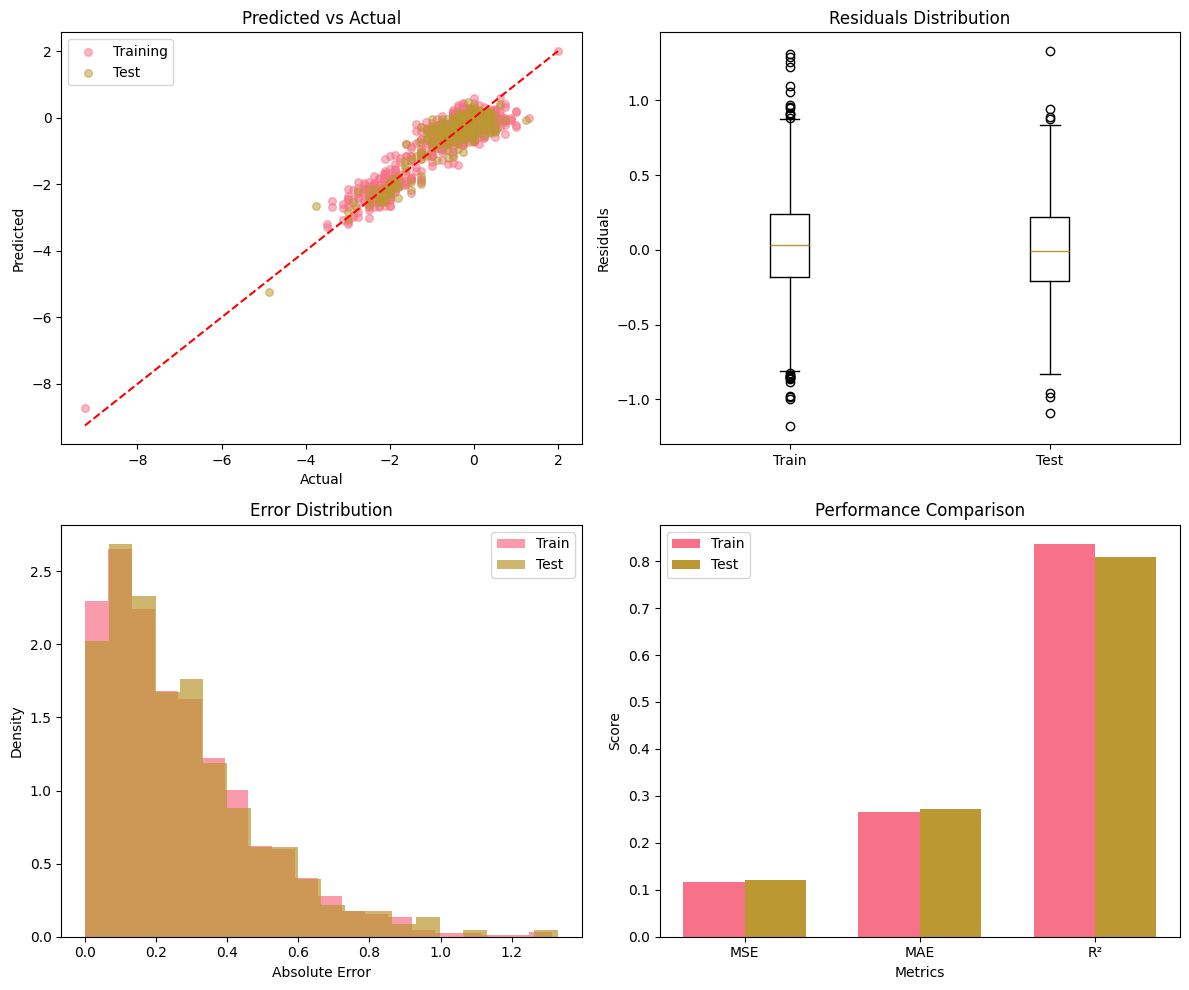

MSE Ratio (Test/Train): 1.039
 Good generalization


In [17]:
# visual overfitting check
def quick_overfit_plot(estimator, X_train, y_train, X_test, y_test):
    """Fast visual check for overfitting"""
    print("\nQuick Visual Overfitting Check...")

    # Get predictions
    y_pred_train = estimator.predict(X_train)
    y_pred_test = estimator.predict(X_test)

    # Create comparison plot
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

    # Plot 1: Predicted vs Actual for both sets
    ax1.scatter(y_train, y_pred_train, alpha=0.5, label='Training', s=30)
    ax1.scatter(y_test, y_pred_test, alpha=0.5, label='Test', s=30)
    ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
    ax1.set_xlabel('Actual')
    ax1.set_ylabel('Predicted')
    ax1.legend()
    ax1.set_title('Predicted vs Actual')

    # Plot 2: Residuals comparison
    residuals_train = y_train - y_pred_train
    residuals_test = y_test - y_pred_test
    ax2.boxplot([residuals_train, residuals_test], labels=['Train', 'Test'])
    ax2.set_ylabel('Residuals')
    ax2.set_title('Residuals Distribution')

    # Plot 3: Error distribution
    errors_train = np.abs(residuals_train)
    errors_test = np.abs(residuals_test)
    ax3.hist(errors_train, alpha=0.7, label='Train', bins=20, density=True)
    ax3.hist(errors_test, alpha=0.7, label='Test', bins=20, density=True)
    ax3.set_xlabel('Absolute Error')
    ax3.set_ylabel('Density')
    ax3.legend()
    ax3.set_title('Error Distribution')

    # Plot 4: Performance metrics
    metrics = ['MSE', 'MAE', 'R²']
    train_vals = [mean_squared_error(y_train, y_pred_train),
                 mean_absolute_error(y_train, y_pred_train),
                 r2_score(y_train, y_pred_train)]
    test_vals = [mean_squared_error(y_test, y_pred_test),
                mean_absolute_error(y_test, y_pred_test),
                r2_score(y_test, y_pred_test)]

    x = np.arange(len(metrics))
    width = 0.35
    ax4.bar(x - width/2, train_vals, width, label='Train')
    ax4.bar(x + width/2, test_vals, width, label='Test')
    ax4.set_xlabel('Metrics')
    ax4.set_ylabel('Score')
    ax4.set_xticks(x)
    ax4.set_xticklabels(metrics)
    ax4.legend()
    ax4.set_title('Performance Comparison')

    plt.tight_layout()
    plt.show()

    # Quick assessment
    mse_ratio = test_vals[0] / train_vals[0]
    print(f"MSE Ratio (Test/Train): {mse_ratio:.3f}")
    if mse_ratio > 1.15:
        print(" Significant overfitting likely")
    elif mse_ratio > 1.05:
        print(" Mild overfitting possible")
    else:
        print(" Good generalization")

# Run the visual check
quick_overfit_plot(stacking_reg, X_train_scaled, y_train, X_test_scaled, y_test)


Generating Quick Learning Curve...


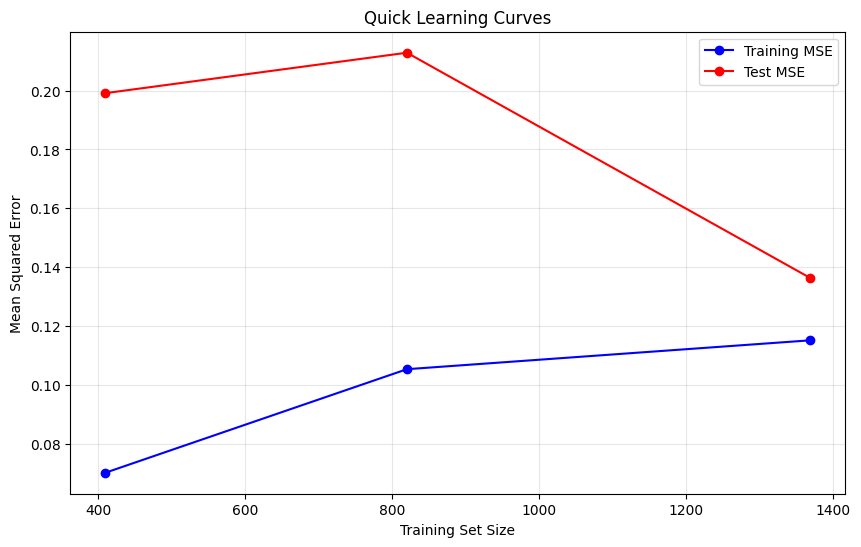

Final Train-Test Gap: -0.0212
 Good generalization


In [18]:
# Faster learning curve with fewer data points
def quick_learning_curve(estimator, X, y, train_sizes=[0.3, 0.6, 1.0], cv=3):
    """Faster learning curve with fewer points"""
    print("\nGenerating Quick Learning Curve...")

    train_errors, test_errors = [], []

    for size in train_sizes:
        n_samples = int(len(X) * size)
        X_subset = X[:n_samples]
        y_subset = y[:n_samples]

        # Simple train/test split instead of CV for speed
        X_tr, X_te, y_tr, y_te = train_test_split(X_subset, y_subset, test_size=0.2, random_state=42)

        estimator.fit(X_tr, y_tr)
        train_errors.append(mean_squared_error(y_tr, estimator.predict(X_tr)))
        test_errors.append(mean_squared_error(y_te, estimator.predict(X_te)))

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot([int(len(X)*s) for s in train_sizes], train_errors, 'o-', color='blue', label='Training MSE')
    plt.plot([int(len(X)*s) for s in train_sizes], test_errors, 'o-', color='red', label='Test MSE')
    plt.xlabel('Training Set Size')
    plt.ylabel('Mean Squared Error')
    plt.title('Quick Learning Curves')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Analysis
    final_gap = train_errors[-1] - test_errors[-1]
    print(f"Final Train-Test Gap: {final_gap:.4f}")
    if final_gap > test_errors[-1] * 0.3:
        print(" Potential overfitting")
    else:
        print(" Good generalization")

# Run the quick version
quick_learning_curve(stacking_reg, X_train_scaled, y_train)


Running Bootstrap Overfitting Check...
Completed 10/30 bootstraps
Completed 20/30 bootstraps
Completed 30/30 bootstraps


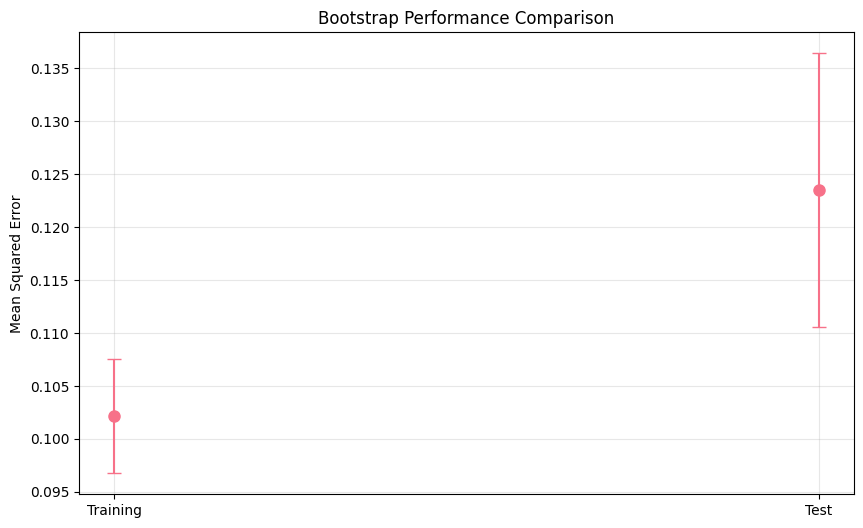


Bootstrap Results:
Training MSE: 0.102163 ± 0.005407
Test MSE:     0.123506 ± 0.012931
Test/Train Ratio: 1.209


In [19]:
# Bootstrap validation for overfitting detection
def bootstrap_overfit_check(estimator, X, y, n_bootstraps=50, test_size=0.2):
    """Use bootstrap to check overfitting"""
    print("\nRunning Bootstrap Overfitting Check...")

    train_scores, test_scores = [], []

    for i in range(n_bootstraps):
        # Bootstrap sample
        indices = np.random.choice(len(X), len(X), replace=True)
        X_boot = X.iloc[indices] if hasattr(X, 'iloc') else X[indices]
        y_boot = y.iloc[indices] if hasattr(y, 'iloc') else y[indices]

        # Train/test split
        X_tr, X_te, y_tr, y_te = train_test_split(X_boot, y_boot, test_size=test_size, random_state=i)

        # Fit and score
        estimator.fit(X_tr, y_tr)
        train_scores.append(mean_squared_error(y_tr, estimator.predict(X_tr)))
        test_scores.append(mean_squared_error(y_te, estimator.predict(X_te)))

        if (i + 1) % 10 == 0:
            print(f"Completed {i+1}/{n_bootstraps} bootstraps")

    # Analysis
    train_mean, train_std = np.mean(train_scores), np.std(train_scores)
    test_mean, test_std = np.mean(test_scores), np.std(test_scores)

    plt.figure(figsize=(10, 6))
    plt.errorbar([0, 1], [train_mean, test_mean], yerr=[train_std, test_std],
                 fmt='o', capsize=5, markersize=8)
    plt.xticks([0, 1], ['Training', 'Test'])
    plt.ylabel('Mean Squared Error')
    plt.title('Bootstrap Performance Comparison')
    plt.grid(True, alpha=0.3)
    plt.show()

    ratio = test_mean / train_mean
    print(f"\nBootstrap Results:")
    print(f"Training MSE: {train_mean:.6f} ± {train_std:.6f}")
    print(f"Test MSE:     {test_mean:.6f} ± {test_std:.6f}")
    print(f"Test/Train Ratio: {ratio:.3f}")

    return ratio

# Run bootstrap check (faster than full learning curve)
bootstrap_ratio = bootstrap_overfit_check(stacking_reg, X_train_scaled, y_train, n_bootstraps=30)

In [20]:
# =============================================================================
# ERROR PATTERN ANALYSIS FUNCTION
# =============================================================================

def identify_error_patterns(X_test_df, y_test_actual, y_test_predicted, features, error_threshold=0.5):
    """
    Identify patterns in features that lead to wrong predictions

    Parameters:
    - X_test_df: DataFrame with test features (before scaling)
    - y_test_actual: Actual target values
    - y_test_predicted: Predicted target values
    - error_threshold: Threshold for considering a prediction as "wrong"
    """
    import numpy as np
    import pandas as pd

    actual = y_test_actual
    predicted = y_test_predicted
    abs_errors = np.abs(actual - predicted)

    # Create analysis DataFrame with features
    analysis_df = pd.DataFrame({
        'SEQ_actual': actual,
        'SEQ_pred': predicted,
        'Abs_Error': abs_errors,
        'Wrong_Pred': abs_errors > error_threshold
    })

    # Add features to analysis (using original unscaled values for interpretability)
    for feature in features:
        if feature in X_test_df.columns:
            analysis_df[feature] = X_test_df[feature].values

    # Analyze wrong predictions
    wrong_preds = analysis_df[analysis_df['Wrong_Pred'] == True]
    correct_preds = analysis_df[analysis_df['Wrong_Pred'] == False]



    print(f"Correct predictions: ({len(correct_preds)/len(analysis_df)*100:.1f}%)")
    print(f"Wrong predictions (error > {error_threshold}): ({len(wrong_preds)/len(analysis_df)*100:.1f}%)")


    # Analyze by SEQ prediction ranges
    seq_ranges = [
        (-3.0, -2.0, 'Very Negativee'),
        (-2.0, -1.0, 'Negative'),
        (-1.0, -0.5, 'Mild Negative'),
        (-0.5, 0.0, 'Near Zero Negative'),
        (0.0, 0.5, 'Positive')
    ]

    for min_val, max_val, range_name in seq_ranges:
        in_range = (analysis_df['SEQ_actual'] >= min_val) & (analysis_df['SEQ_actual'] < max_val)
        range_data = analysis_df[in_range]

        if len(range_data) > 0:
            wrong_in_range = range_data['Wrong_Pred'].sum()
            total_in_range = len(range_data)
            wrong_pct = (wrong_in_range / total_in_range) * 100
            mean_error = range_data['Abs_Error'].mean()

            print(f"\n ({min_val} to {max_val}):")
            print(f"  Total cases: {total_in_range}")
            print(f"  Mean absolute error: {mean_error:.4f}")





# =============================================================================
# CALL THE ERROR PATTERN ANALYSIS FUNCTION
# =============================================================================

print(f"\n{'='*60}")
print(f"=== ERROR PATTERN ANALYSIS, Accuracy Thresholds Within ±0.50 D ===")
print(f"{'='*60}")

# Call the function with your test data
pattern_analysis = identify_error_patterns(
    X_test_df=X_test,  # Use the original unscaled test features
    y_test_actual=y_test,
    y_test_predicted=y_pred,
    features=features,
    error_threshold=0.5  # Adjust this threshold as needed
)



=== ERROR PATTERN ANALYSIS, Accuracy Thresholds Within ±0.50 D ===
Correct predictions: (85.1%)
Wrong predictions (error > 0.5): (14.9%)

 (-3.0 to -2.0):
  Total cases: 22
  Mean absolute error: 0.1947

 (-2.0 to -1.0):
  Total cases: 36
  Mean absolute error: 0.3209

 (-1.0 to -0.5):
  Total cases: 51
  Mean absolute error: 0.3549

 (-0.5 to 0.0):
  Total cases: 134
  Mean absolute error: 0.1915

 (0.0 to 0.5):
  Total cases: 89
  Mean absolute error: 0.2865


In [21]:
#Check PREDICTION PERFORMANCE- Percentage of cases with an absolute error Thresholds: 0.25 D, 0.50 D, 0.75 D, 1.00 D
def simple_error_threshold_table(y_true, y_pred, thresholds=[0.25, 0.50, 0.75, 1.00]):
    """
    Simple version without external dependencies
    """
    abs_errors = np.abs(y_true - y_pred)
    total_cases = len(y_true)

    print("="*60)
    print("ABSOLUTE ERROR THRESHOLD ANALYSIS")
    print("="*60)
    print(f"Total cases: {total_cases}")
    print(f"Overall MAE: {np.mean(abs_errors):.4f} D")
    print()

    print("Threshold (D) | Cases Within | Percentage (%) | Cumulative %")
    print("-" * 65)

    cumulative_percentage = 0
    for threshold in thresholds:
        within_threshold = np.sum(abs_errors <= threshold)
        percentage = (within_threshold / total_cases) * 100
        cumulative_percentage += percentage

        print(f"{threshold:^12.2f} | {within_threshold:^12} | {percentage:^13.1f}% | {cumulative_percentage:^12.1f}%")

    # Additional useful metrics
    print(f"\nKey Metrics:")
    print(f"- Percentage within 0.25 D: {(np.sum(abs_errors <= 0.25) / total_cases * 100):.1f}%")
    print(f"- Percentage within 0.50 D: {(np.sum(abs_errors <= 0.50) / total_cases * 100):.1f}%")
    print(f"- Percentage within 0.75 D: {(np.sum(abs_errors <= 0.75) / total_cases * 100):.1f}%")
    print(f"- Percentage within 1.00 D: {(np.sum(abs_errors <= 1.00) / total_cases * 100):.1f}%")

    return abs_errors

abs_errors = simple_error_threshold_table(y_test, y_pred)

ABSOLUTE ERROR THRESHOLD ANALYSIS
Total cases: 342
Overall MAE: 0.2711 D

Threshold (D) | Cases Within | Percentage (%) | Cumulative %
-----------------------------------------------------------------
    0.25     |     187      |     54.7     % |     54.7    %
    0.50     |     291      |     85.1     % |    139.8    %
    0.75     |     329      |     96.2     % |    236.0    %
    1.00     |     340      |     99.4     % |    335.4    %

Key Metrics:
- Percentage within 0.25 D: 54.7%
- Percentage within 0.50 D: 85.1%
- Percentage within 0.75 D: 96.2%
- Percentage within 1.00 D: 99.4%



=== POSTOPERATIVE REFRACTION PREDICTION PERFORMANCE BY AXIAL LENGTH GROUPS ===
+--------------------------+-------------+------------------+----------------+-----------+------------+-------+---------------+---------------+---------------+---------------+
|         AL Group         |  Cases (n)  |  Percentage (%)  |  Mean AL (mm)  |  MAE (D)  |  RMSE (D)  |  R²   |  ≤0.25 D (%)  |  ≤0.50 D (%)  |  ≤0.75 D (%)  |  ≤1.00 D (%)  |
+==========================+=============+==================+================+===========+============+=======+===============+===============+===============+===============+
|   Short AL (<22.0 mm)    |     40      |       11.7       |     21.16      |   0.39    |    0.47    | 0.341 |      35       |      70       |     92.5      |     97.5      |
+--------------------------+-------------+------------------+----------------+-----------+------------+-------+---------------+---------------+---------------+---------------+
| Medium AL (22.0-26.0 mm) |     274    

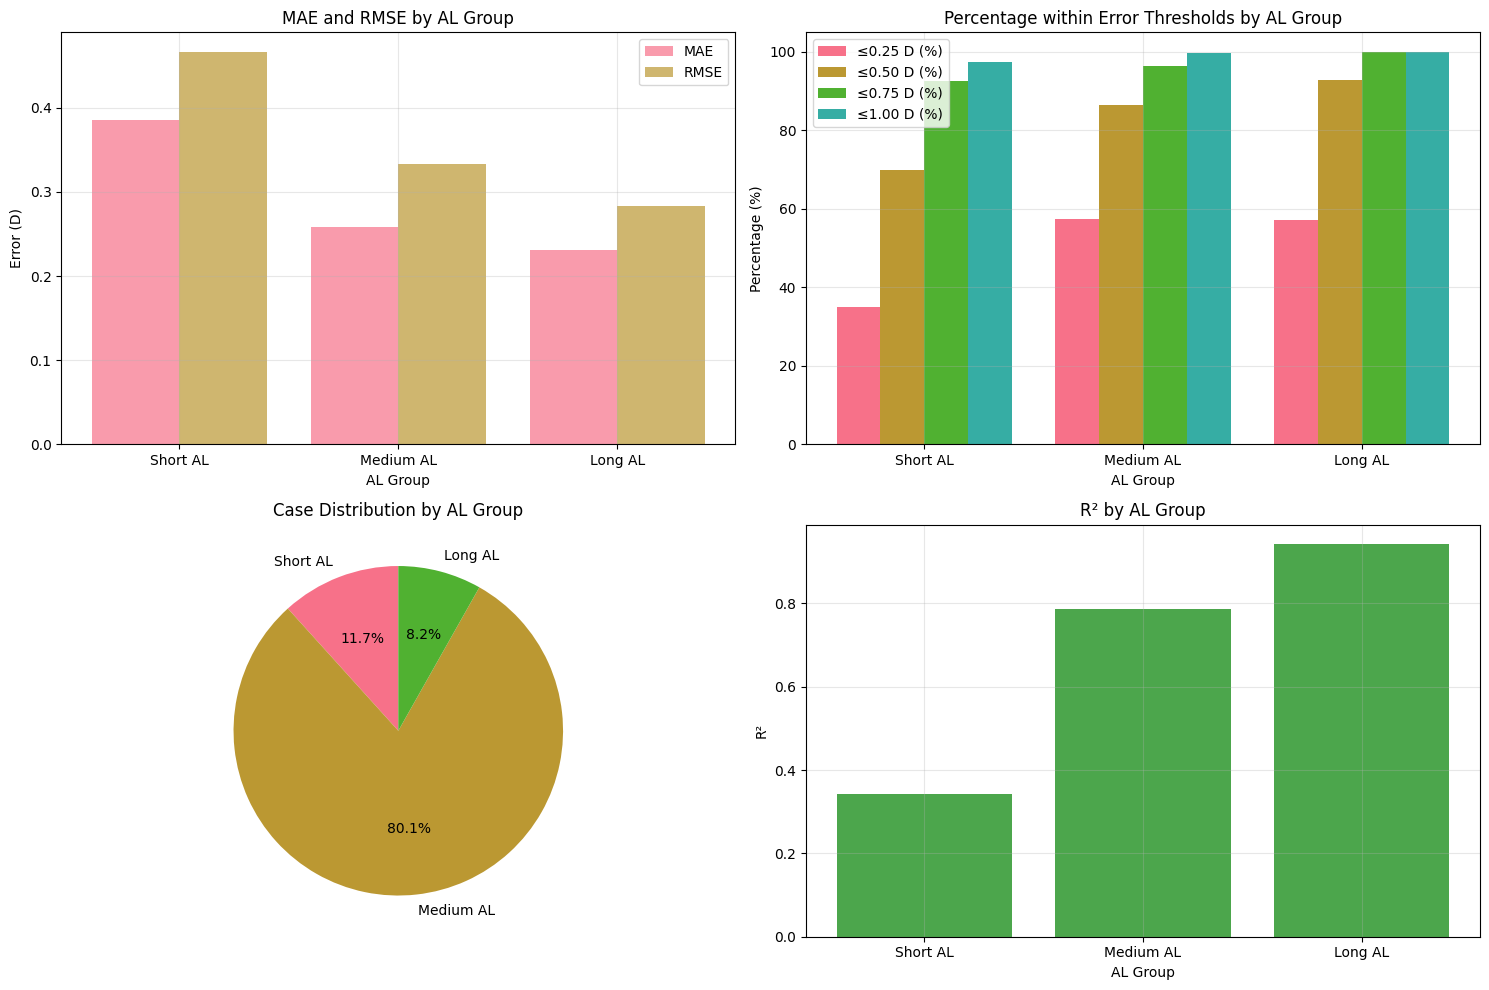


=== DETAILED GROUP STATISTICS ===
Overall AL statistics in test set:
- Min AL: 20.19 mm
- Max AL: 29.47 mm
- Mean AL: 23.67 mm
- Std AL: 1.52 mm


In [22]:
# Check PREDICTION PERFORMANCE BY AXIAL LENGTH GROUPS
import pandas as pd
import numpy as np
from tabulate import tabulate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def analyze_al_groups_performance(X_test, y_test, y_pred, al_column='AL'):
    """
    Analyze prediction performance in short/medium/long AL groups

    Parameters:
    - X_test: Test features DataFrame (should contain AL column)
    - y_test: Actual target values
    - y_pred: Predicted target values
    - al_column: Name of the axial length column

    Returns:
    - DataFrame with performance metrics for each AL group
    """

    # Create results DataFrame
    results_df = pd.DataFrame({
        'Actual': y_test.values,
        'Predicted': y_pred,
        'AL': X_test[al_column].values
    })

    # Define AL groups
    short_mask = results_df['AL'] < 22.0
    medium_mask = (results_df['AL'] >= 22.0) & (results_df['AL'] <= 26.0)
    long_mask = results_df['AL'] > 26.0

    # Initialize results storage
    groups = ['Short AL (<22.0 mm)', 'Medium AL (22.0-26.0 mm)', 'Long AL (>26.0 mm)', 'Overall']
    masks = [short_mask, medium_mask, long_mask, pd.Series([True] * len(results_df))]

    performance_data = []

    for group_name, mask in zip(groups, masks):
        if mask.sum() > 0:  # Check if group has cases
            y_true_group = results_df.loc[mask, 'Actual']
            y_pred_group = results_df.loc[mask, 'Predicted']
            al_values = results_df.loc[mask, 'AL']

            # Calculate metrics
            mae = mean_absolute_error(y_true_group, y_pred_group)
            rmse = np.sqrt(mean_squared_error(y_true_group, y_pred_group))
            r2 = r2_score(y_true_group, y_pred_group)
            mean_al = al_values.mean()
            n_cases = len(y_true_group)

            # Error threshold percentages
            abs_errors = np.abs(y_true_group - y_pred_group)
            within_025 = (abs_errors <= 0.25).sum() / n_cases * 100
            within_050 = (abs_errors <= 0.50).sum() / n_cases * 100
            within_075 = (abs_errors <= 0.75).sum() / n_cases * 100
            within_100 = (abs_errors <= 1.00).sum() / n_cases * 100

            performance_data.append({
                'AL Group': group_name,
                'Cases (n)': n_cases,
                'Percentage (%)': (n_cases / len(results_df)) * 100,
                'Mean AL (mm)': mean_al,
                'MAE (D)': mae,
                'RMSE (D)': rmse,
                'R²': r2,
                '≤0.25 D (%)': within_025,
                '≤0.50 D (%)': within_050,
                '≤0.75 D (%)': within_075,
                '≤1.00 D (%)': within_100
            })

    return pd.DataFrame(performance_data)

def display_al_groups_table(performance_df):
    """
    Display formatted table for AL groups performance
    """


    # Create display dataframe with rounded values
    display_df = performance_df.copy()
    numeric_cols = ['Percentage (%)', 'Mean AL (mm)', 'MAE (D)', 'RMSE (D)', 'R²',
                   '≤0.25 D (%)', '≤0.50 D (%)', '≤0.75 D (%)', '≤1.00 D (%)']

    for col in numeric_cols:
        if col in display_df.columns:
            if col == 'R²':
                display_df[col] = display_df[col].round(3)
            else:
                display_df[col] = display_df[col].round(2)

    # Display using tabulate
    print(tabulate(display_df,
                  headers='keys',
                  tablefmt='grid',
                  showindex=False,
                  numalign='center',
                  stralign='center'))

    return display_df

def plot_al_groups_performance(performance_df):
    """
    Create visualization for AL groups performance
    """
    import matplotlib.pyplot as plt

    # Filter out Overall group for plotting
    plot_df = performance_df[performance_df['AL Group'] != 'Overall'].copy()

    if len(plot_df) == 0:
        return

    # Create subplots
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

    # Plot 1: MAE and RMSE by AL group
    groups = plot_df['AL Group']
    x_pos = np.arange(len(groups))

    ax1.bar(x_pos - 0.2, plot_df['MAE (D)'], 0.4, label='MAE', alpha=0.7)
    ax1.bar(x_pos + 0.2, plot_df['RMSE (D)'], 0.4, label='RMSE', alpha=0.7)
    ax1.set_xlabel('AL Group')
    ax1.set_ylabel('Error (D)')
    ax1.set_title('MAE and RMSE by AL Group')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([g.split('(')[0].strip() for g in groups])
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Plot 2: Percentage within error thresholds
    thresholds = ['≤0.25 D (%)', '≤0.50 D (%)', '≤0.75 D (%)', '≤1.00 D (%)']
    for i, threshold in enumerate(thresholds):
        ax2.bar(x_pos + (i-1.5)*0.2, plot_df[threshold], 0.2, label=threshold)

    ax2.set_xlabel('AL Group')
    ax2.set_ylabel('Percentage (%)')
    ax2.set_title('Percentage within Error Thresholds by AL Group')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([g.split('(')[0].strip() for g in groups])
    ax2.legend()
    ax2.grid(alpha=0.3)

    # Plot 3: Case distribution
    ax3.pie(plot_df['Cases (n)'], labels=[g.split('(')[0].strip() for g in groups],
            autopct='%1.1f%%', startangle=90)
    ax3.set_title('Case Distribution by AL Group')

    # Plot 4: R² values
    ax4.bar(x_pos, plot_df['R²'], alpha=0.7, color='green')
    ax4.set_xlabel('AL Group')
    ax4.set_ylabel('R²')
    ax4.set_title('R² by AL Group')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels([g.split('(')[0].strip() for g in groups])
    ax4.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# =============================================================================
# AXIAL LENGTH GROUP ANALYSIS
# =============================================================================

print(f"\n{'='*100}")
print(f"=== POSTOPERATIVE REFRACTION PREDICTION PERFORMANCE BY AXIAL LENGTH GROUPS ===")
print(f"{'='*100}")

# Perform AL group analysis
al_performance_df = analyze_al_groups_performance(X_test, y_test, y_pred, al_column='AL')

# Display the table
display_df = display_al_groups_table(al_performance_df)

# Additional statistical analysis
print(f"\n{'='*60}")
print(f"=== STATISTICAL ANALYSIS ===")
print(f"{'='*60}")

# Check if we have all three groups
groups_present = [group for group in ['Short AL (<22.0 mm)', 'Medium AL (22.0-26.0 mm)', 'Long AL (>26.0 mm)']
                  if group in al_performance_df['AL Group'].values]

if len(groups_present) >= 2:
    print(f"Groups analyzed: {', '.join(groups_present)}")

    # Compare performance between groups
    overall_mae = al_performance_df[al_performance_df['AL Group'] == 'Overall']['MAE (D)'].values[0]

    for group in groups_present:
        group_mae = al_performance_df[al_performance_df['AL Group'] == group]['MAE (D)'].values[0]
        difference = group_mae - overall_mae


        print(f"- {group}: MAE = {group_mae:.3f} ")

# Create visualizations
plot_al_groups_performance(al_performance_df)

# Optional: Save detailed results
print(f"\n{'='*60}")
print(f"=== DETAILED GROUP STATISTICS ===")
print(f"{'='*60}")

# Show AL distribution statistics
print(f"Overall AL statistics in test set:")
print(f"- Min AL: {X_test['AL'].min():.2f} mm")
print(f"- Max AL: {X_test['AL'].max():.2f} mm")
print(f"- Mean AL: {X_test['AL'].mean():.2f} mm")
print(f"- Std AL: {X_test['AL'].std():.2f} mm")

# Show group-wise AL ranges
short_al = X_test[X_test['AL'] < 22.0]['AL']
medium_al = X_test[(X_test['AL'] >= 22.0) & (X_test['AL'] <= 26.0)]['AL']
long_al = X_test[X_test['AL'] > 26.0]['AL']



In [ ]:
# === check Mean signed error (bias) ===


eval_df = pd.DataFrame({
    'y_true': y_test.values,
    'y_pred': y_pred
}, index=X_test.index)
eval_df['error'] = eval_df['y_true'] - eval_df['y_pred']
eval_df['abs_error'] = eval_df['error'].abs()

# Add feature columns from X_test to eval_df
for feature in features:
    if feature in X_test.columns:
        eval_df[feature] = X_test[feature]

# Add Axial Length bins for plotting
al_bins = [0, 22, 26, float('inf')] # Define bins
al_labels = ['Short (<22 mm)', 'Normal (22–26 mm)', 'Long (>26 mm)']
eval_df['AL_bin'] = pd.cut(eval_df['AL'], bins=al_bins, labels=al_labels, right=False)


# 1) Mean signed error (bias) and its 95% CI
n = len(eval_df)
bias = eval_df['error'].mean()
sd_err = eval_df['error'].std(ddof=1)
bias_ci_lo = bias - 1.96 * sd_err / np.sqrt(n)
bias_ci_hi = bias + 1.96 * sd_err / np.sqrt(n)
print(f"\nMean signed error (bias): {bias:.3f} D [95% CI {bias_ci_lo:.3f} to {bias_ci_hi:.3f}]")


Mean signed error (bias): 0.013 D [95% CI -0.023 to 0.050]



GENERATING COMPREHENSIVE EVALUATION PLOTS...


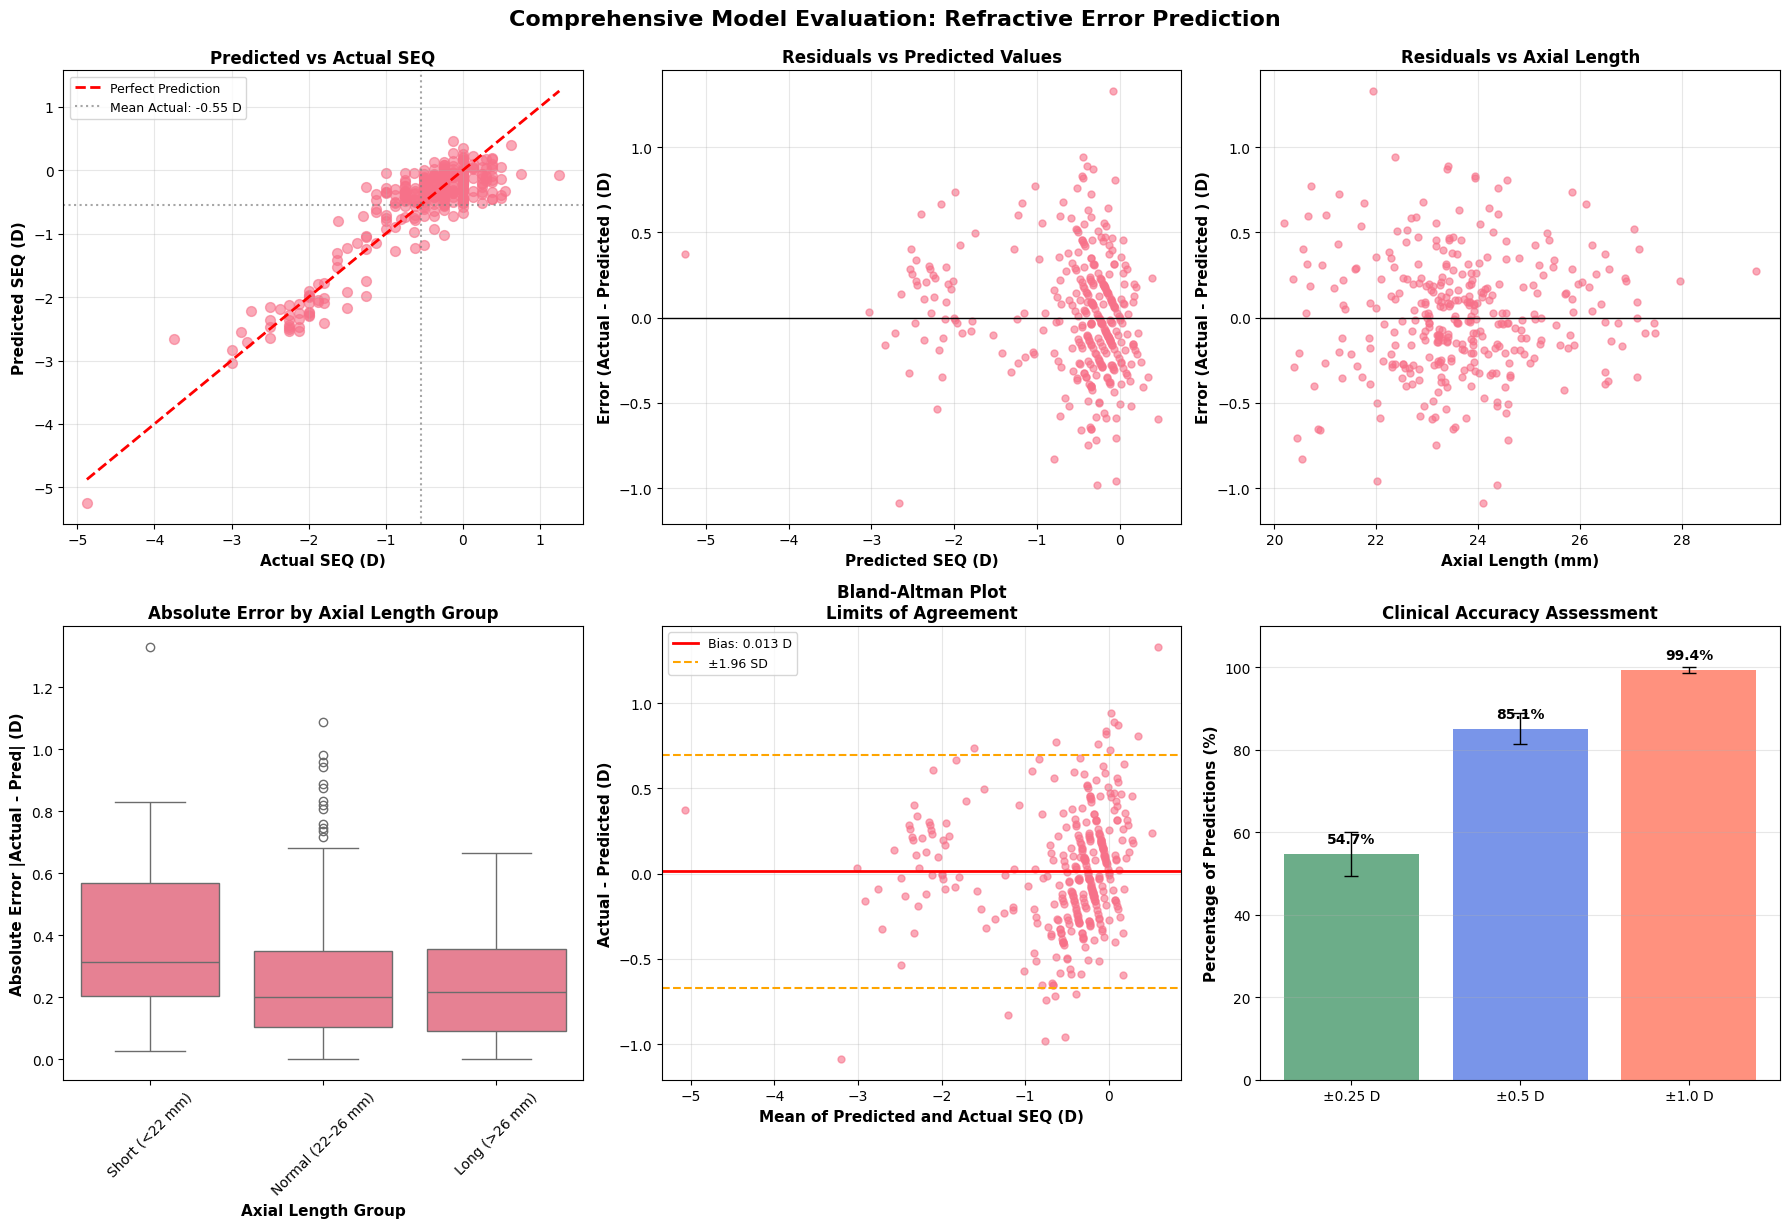


MODEL PERFORMANCE SUMMARY
Mean Absolute Error (MAE): 0.271 D
Bland-Altman Bias: 0.013 D, SD: 0.348 D
Limits of Agreement: [-0.669, 0.696] D

Clinical Accuracy:
Within ±0.25 D: 54.7% 
Within ±0.50 D: 85.1% 
Within ±1.00 D: 99.4% 


In [ ]:
# =============================================================================
# COMPREHENSIVE MODEL EVALUATION VISUALIZATION
# =============================================================================

print("\n" + "="*60)
print("GENERATING COMPREHENSIVE EVALUATION PLOTS...")
print("="*60)

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter
import statsmodels.stats.api as sms # Import for confidence interval calculation

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")
fig = plt.figure(figsize=(18, 12))

# =============================================================================
# PLOT 1: Predicted vs Actual (Top-left)
# =============================================================================
ax1 = plt.subplot(2, 3, 1)
scatter1 = ax1.scatter(y_test, y_pred, alpha=0.6, s=50)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')

# Calculate MAE and add to plot
mae = mean_absolute_error(y_test, y_pred)
ax1.axhline(y=y_test.mean(), color='gray', linestyle=':', alpha=0.7, label=f'Mean Actual: {y_test.mean():.2f} D')
ax1.axvline(x=y_test.mean(), color='gray', linestyle=':', alpha=0.7)

# Customize the first plot
ax1.set_xlabel('Actual SEQ (D)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Predicted SEQ (D)', fontsize=11, fontweight='bold')
ax1.set_title('Predicted vs Actual SEQ'.format(mae), fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)


# =============================================================================
# PLOT 2: Residuals vs Predicted (Top-middle)
# =============================================================================
ax2 = plt.subplot(2, 3, 2)
scatter2 = ax2.scatter(eval_df['y_pred'], eval_df['error'], s=25, alpha=0.6)
ax2.axhline(0, color='k', lw=1)
ax2.set_xlabel('Predicted SEQ (D)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Error (Actual - Predicted ) (D)', fontsize=11, fontweight='bold')
ax2.set_title('Residuals vs Predicted Values', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# =============================================================================
# PLOT 3: Residuals vs Axial Length (Top-right)
# =============================================================================
ax3 = plt.subplot(2, 3, 3)
scatter3 = ax3.scatter(eval_df['AL'], eval_df['error'], s=25, alpha=0.6)
ax3.axhline(0, color='k', lw=1)
ax3.set_xlabel('Axial Length (mm)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Error (Actual - Predicted ) (D)', fontsize=11, fontweight='bold')
ax3.set_title('Residuals vs Axial Length', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# =============================================================================
# PLOT 4: Absolute Error by AL Groups (Bottom-left)
# =============================================================================
ax4 = plt.subplot(2, 3, 4)
al_order = ['Short (<22 mm)', 'Normal (22–26 mm)', 'Long (>26 mm)']
sns.boxplot(ax=ax4, x='AL_bin', y='abs_error', data=eval_df, order=al_order)
ax4.set_xlabel('Axial Length Group', fontsize=11, fontweight='bold')
ax4.set_ylabel('Absolute Error |Actual - Pred| (D)', fontsize=11, fontweight='bold')
ax4.set_title('Absolute Error by Axial Length Group', fontsize=12, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)

# =============================================================================
# PLOT 5: Bland-Altman Plot (Bottom-middle)
# =============================================================================
ax5 = plt.subplot(2, 3, 5)
mean_pair = (eval_df['y_pred'] + eval_df['y_true']) / 2
diff = eval_df['error']  
ba_bias = diff.mean()
ba_sd = diff.std(ddof=1)

scatter5 = ax5.scatter(mean_pair, diff, s=25, alpha=0.6)
ax5.axhline(ba_bias, color='r', lw=2, label=f'Bias: {ba_bias:.3f} D')
ax5.axhline(ba_bias + 1.96*ba_sd, color='orange', ls='--', lw=1.5, label='±1.96 SD')
ax5.axhline(ba_bias - 1.96*ba_sd, color='orange', ls='--', lw=1.5)
ax5.set_xlabel('Mean of Predicted and Actual SEQ (D)', fontsize=11, fontweight='bold')
ax5.set_ylabel('Actual - Predicted (D)', fontsize=11, fontweight='bold')
ax5.set_title('Bland-Altman Plot\nLimits of Agreement', fontsize=12, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)


# =============================================================================
# PLOT 6: Clinical Accuracy (Bottom-right)
# =============================================================================
ax6 = plt.subplot(2, 3, 6)

# Calculate clinical accuracy percentages and confidence intervals
thresholds = [0.25, 0.5, 1.0]
pct_values = []
ci_lo = []
ci_hi = []
n = len(eval_df)

for t in thresholds:
    within_threshold = eval_df[eval_df['abs_error'] <= t]
    count = len(within_threshold)
    pct = (count / n) * 100
    pct_values.append(pct)

    # Calculate confidence interval for proportion
    if count > 0 and count < n:
        ci = sms.proportion_confint(count, n, alpha=0.05, method='normal')
        ci_lo.append(ci[0] * 100)
        ci_hi.append(ci[1] * 100)
    else:
        ci_lo.append(pct) # No variation, CI is just the percentage
        ci_hi.append(pct)


bars = ax6.bar([f'±{t} D' for t in thresholds], pct_values,
               color=['#2E8B57', '#4169E1', '#FF6347'], alpha=0.7)

# Add error bars for confidence intervals
for i, (bar, lo, hi) in enumerate(zip(bars, ci_lo, ci_hi)):
    height = bar.get_height()
    ax6.errorbar(bar.get_x() + bar.get_width()/2, height,
                yerr=[[height - lo], [hi - height]],
                fmt='k', elinewidth=1, capsize=5)

# Add value labels on bars
for i, (bar, pct) in enumerate(zip(bars, pct_values)):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')

ax6.set_ylabel('Percentage of Predictions (%)', fontsize=11, fontweight='bold')
ax6.set_title('Clinical Accuracy Assessment', fontsize=12, fontweight='bold')
ax6.set_ylim(0, 110)
ax6.grid(True, alpha=0.3, axis='y')

# =============================================================================
# Final Layout and Display
# =============================================================================
plt.tight_layout()
plt.suptitle('Comprehensive Model Evaluation: Refractive Error Prediction',
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

# Print numerical summary
print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
# Calculate bias (mean signed error) and its confidence interval
bias = diff.mean()
bias_ci_low, bias_ci_high = sms.DescrStatsW(diff).tconfint_mean()

print(f"Mean Absolute Error (MAE): {mae:.3f} D")
print(f"Bland-Altman Bias: {ba_bias:.3f} D, SD: {ba_sd:.3f} D")
print(f"Limits of Agreement: [{ba_bias - 1.96*ba_sd:.3f}, {ba_bias + 1.96*ba_sd:.3f}] D")
print("\nClinical Accuracy:")
# Recalculate values for printing summary
for t in thresholds:
    within_threshold = eval_df[eval_df['abs_error'] <= t]
    count = len(within_threshold)
    pct = (count / n) * 100
    print(f"Within ±{t:.2f} D: {pct:.1f}% ")
print("="*60)


SHAP ANALYSIS

1. Creating SHAP explainer...


ExactExplainer explainer: 343it [04:57,  1.13it/s]


2. Generating summary plot...


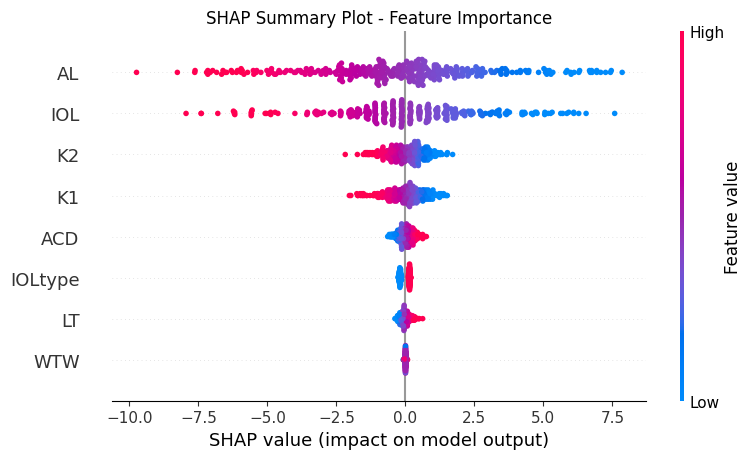

3. Generating feature importance bar plot...


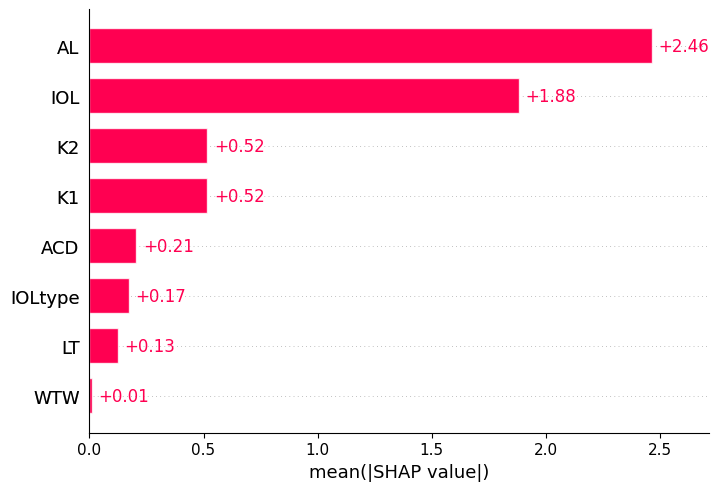

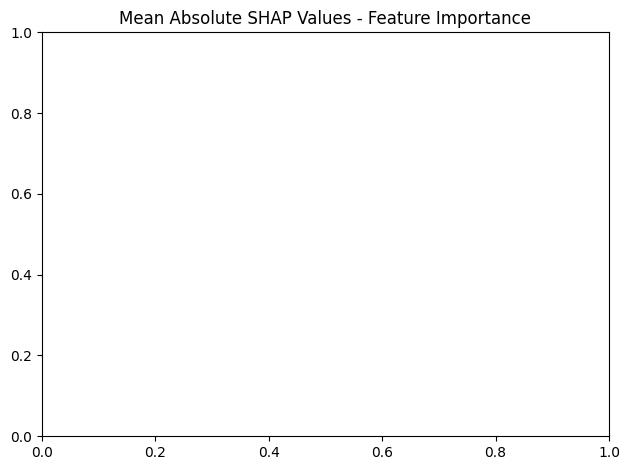

4. Calculating numerical feature importance...

Top 10 Most Important Features:
   feature  importance
3       AL    2.462914
7      IOL    1.881182
5       K2    0.516909
4       K1    0.516707
1      ACD    0.205411
0  IOLtype    0.171533
2       LT    0.125764
6      WTW    0.011035

5. Analyzing individual base models...

--- SHAP Analysis for mlp ---


ExactExplainer explainer: 343it [00:15,  7.16it/s]


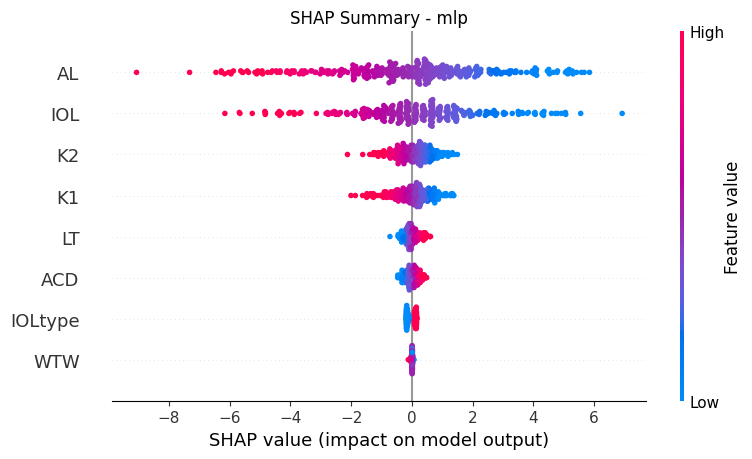

Top 3 features for mlp:
  feature  importance
3      AL    1.990502
7     IOL    1.530765
5      K2    0.463512

--- SHAP Analysis for spline_linear ---


ExactExplainer explainer: 343it [00:18,  8.70it/s]


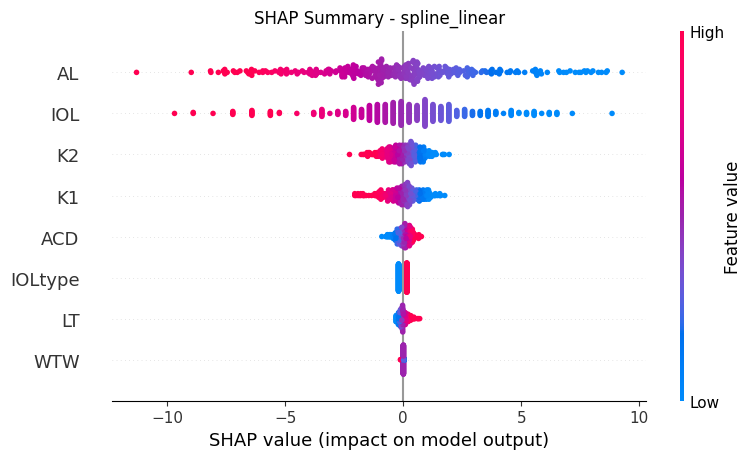

Top 3 features for spline_linear:
  feature  importance
3      AL    2.663987
7     IOL    2.043132
5      K2    0.557428

--- SHAP Analysis for svr ---


ExactExplainer explainer: 343it [03:57,  1.38it/s]


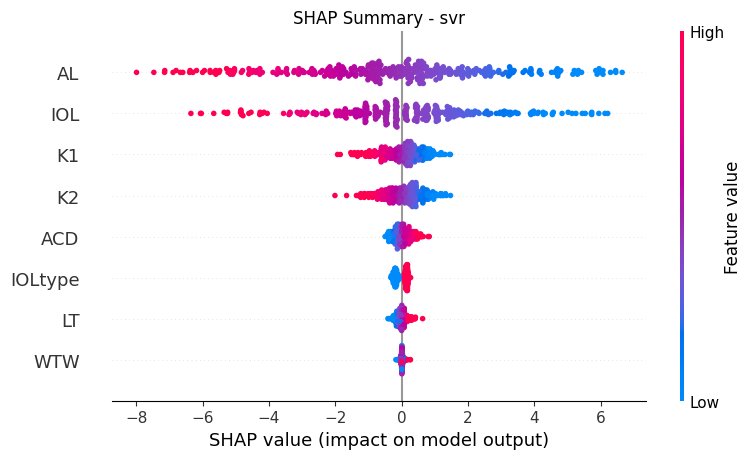

Top 3 features for svr:
  feature  importance
3      AL    2.288070
7     IOL    1.736408
4      K1    0.478007

6. Generating dependency plots for top features...


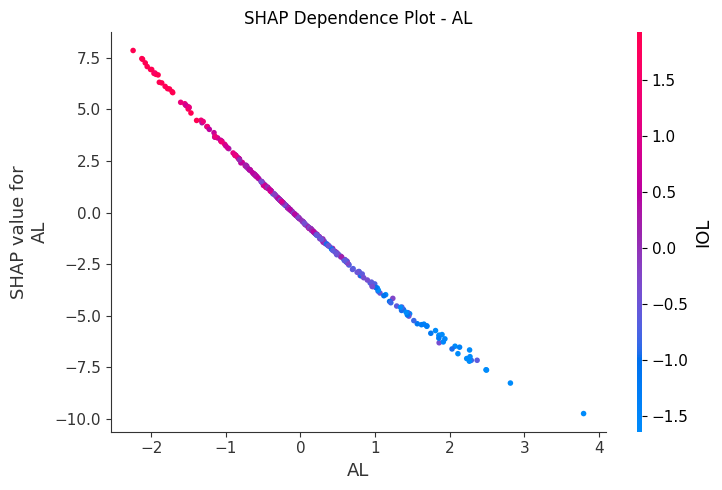

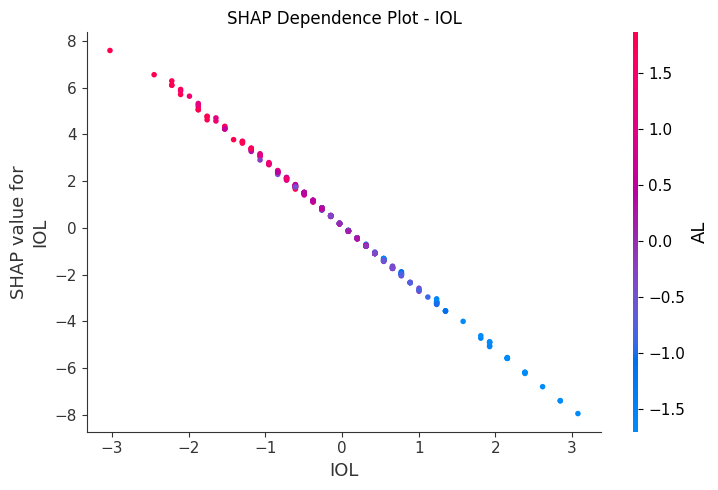

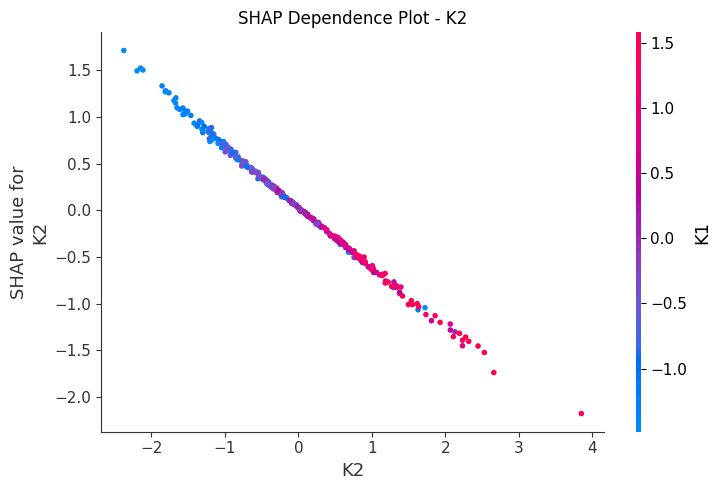


7. Generating waterfall plot for first test sample...


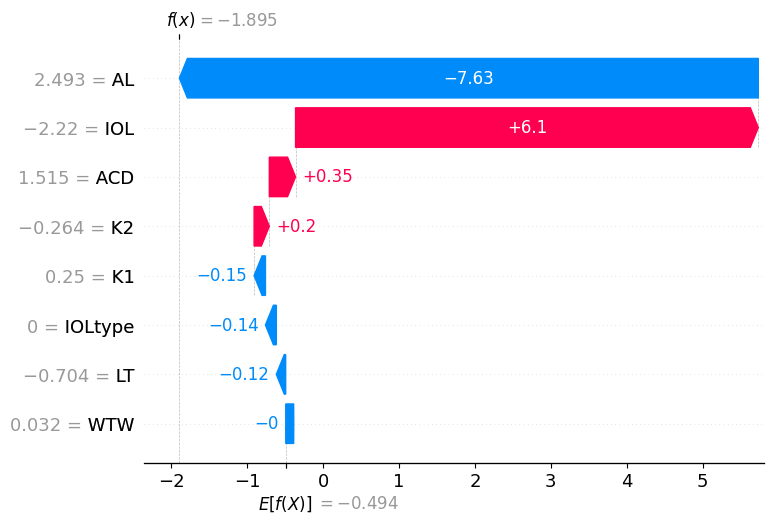

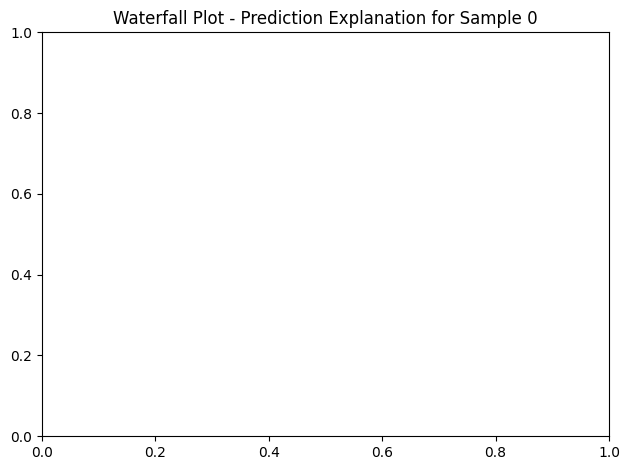


Sample 0 Details:
Actual SEQ: -2.0000
Predicted SEQ: -1.9104
Error: 0.0896

SHAP ANALYSIS COMPLETED


In [25]:
# SHAP ANALYSIS
# =============================================================================

print("\n" + "="*60)
print("SHAP ANALYSIS")
print("="*60)

import shap
import matplotlib.pyplot as plt

# Create SHAP explainer for the stacking model
print("\n1. Creating SHAP explainer...")
explainer = shap.Explainer(stacking_reg.predict, X_train_scaled)
shap_values = explainer(X_test_scaled)

# 1. Summary Plot - Overall Feature Importance
print("2. Generating summary plot...")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=features, show=False)
plt.title("SHAP Summary Plot - Feature Importance")
plt.tight_layout()
plt.show()

# 2. Bar Plot - Mean Absolute SHAP Values
print("3. Generating feature importance bar plot...")
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=len(features))
plt.title("Mean Absolute SHAP Values - Feature Importance")
plt.tight_layout()
plt.show()

# 3. Feature Importance Rankings (Numerical)
print("4. Calculating numerical feature importance...")
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': mean_abs_shap
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

# 4. SHAP Analysis for Individual Base Models
print("\n5. Analyzing individual base models...")
for name, model in stacking_reg.named_estimators_.items():
    print(f"\n--- SHAP Analysis for {name} ---")

    try:
        # Create explainer for individual model
        model_explainer = shap.Explainer(model.predict, X_train_scaled)
        model_shap_values = model_explainer(X_test_scaled)

        # Summary plot for individual model
        plt.figure(figsize=(10, 6))
        shap.summary_plot(model_shap_values, X_test_scaled, feature_names=features, show=False)
        plt.title(f"SHAP Summary - {name}")
        plt.tight_layout()
        plt.show()

        # Calculate feature importance
        model_mean_abs_shap = np.abs(model_shap_values.values).mean(axis=0)
        model_feature_importance = pd.DataFrame({
            'feature': features,
            'importance': model_mean_abs_shap
        }).sort_values('importance', ascending=False)

        print(f"Top 3 features for {name}:")
        print(model_feature_importance.head(3))

    except Exception as e:
        print(f"Could not analyze {name}: {e}")

# 5. Dependency Plots for Top 3 Features
print("\n6. Generating dependency plots for top features...")
top_features = feature_importance.head(3)['feature'].tolist()

for feature in top_features:
    try:
        feature_idx = features.index(feature)
        shap.dependence_plot(
            feature_idx,
            shap_values.values,
            X_test_scaled,
            feature_names=features,
            show=False
        )
        plt.title(f"SHAP Dependence Plot - {feature}")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not create dependence plot for {feature}: {e}")

# 6. Waterfall Plot for a Specific Prediction
print("\n7. Generating waterfall plot for first test sample...")
sample_idx = 0  # First test sample
try:
    plt.figure(figsize=(12, 8))
    shap.plots.waterfall(shap_values[sample_idx], max_display=10)
    plt.title(f"Waterfall Plot - Prediction Explanation for Sample {sample_idx}")
    plt.tight_layout()
    plt.show()

    # Show actual vs predicted
    print(f"\nSample {sample_idx} Details:")
    print(f"Actual SEQ: {y_test.iloc[sample_idx]:.4f}")
    print(f"Predicted SEQ: {y_pred[sample_idx]:.4f}")
    print(f"Error: {abs(y_test.iloc[sample_idx] - y_pred[sample_idx]):.4f}")

except Exception as e:
    print(f"Could not create waterfall plot: {e}")

print("\n" + "="*60)
print("SHAP ANALYSIS COMPLETED")
print("="*60)